# Light-curve reconstructions

Interactive version of `plot_reconstructions.py`. Reuses the same helper functions, so any improvements to the script flow straight through.

Edit the config cell and re-run the rest.

In [3]:
import sys
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Charter", "Bitstream Charter"],
    "font.style": "normal",
})

In [4]:
stats = pd.read_csv('summary.csv')

## Summary plot

In [9]:
stats

,method,k,n_points,n_seqs,mae,rmse,nll,nll_clipped,nll_median_seq,coverage68,coverage95
0,mlp_gaussian,1,1545472,6037,0.616023,0.846475,1.023569,1.019569,1.350800,0.687864,0.943600
1,mlp_gaussian,2,1545472,6037,0.617461,0.850554,1.022427,1.020676,1.351896,0.688909,0.943752
2,mlp_gaussian,4,1545472,6037,0.620132,0.856771,1.032801,1.027100,1.355011,0.691152,0.944771
3,mlp_gaussian,8,1545472,6037,0.623983,0.860025,1.046347,1.038516,1.358148,0.695320,0.946193
4,mlp_gaussian,16,1545472,6037,0.627379,0.869842,1.223843,1.055219,1.359453,0.704381,0.949384
5,mlp_gaussian,32,1545472,6037,0.639131,0.879304,1.133636,1.098974,1.366392,0.714826,0.952566
6,mlp_gaussian,64,1545472,6037,0.660629,0.898243,1.207181,1.184020,1.377222,0.724048,0.954888
7,mlp_gaussian,128,1545472,6037,0.701009,0.933898,1.307345,1.300692,1.393928,0.727145,0.953829
8,mlp_gaussian,256,1545472,6037,0.743878,0.969570,1.382266,1.370968,1.401039,0.721484,0.957433
9,mlp_gaussian,512,1545472,6037,0.781941,0.996453,1.411164,1.405003,1.408683,0.704498,0.960525


In [42]:
methods = ['window_mean', 'mlp_gaussian', 'rnn_flow']
markers = ['o', 's', 'D']
linestyles = [':', '--', '-']
labels = ['window mean', 'MLP', r'EncoTESS']
colors = ['grey', 'plum', 'darkblue']

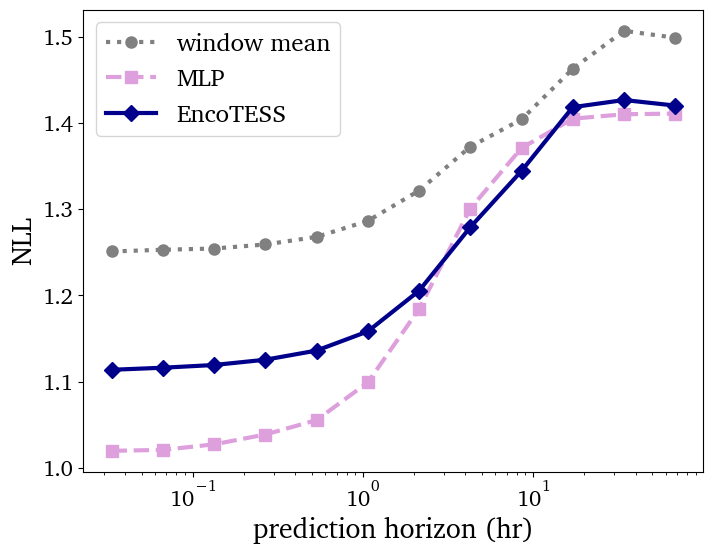

In [45]:
fig,ax = plt.subplots(figsize=(8, 6))
for i in range(len(methods)):
    method = methods[i]
    method_stats = stats[stats['method'] == method]
    plt.plot(method_stats['k']/30, method_stats['nll_clipped'], label=labels[i], marker=markers[i],
             linestyle=linestyles[i], linewidth=3, markersize=8, color=colors[i])

plt.xscale('log')
plt.xlabel('prediction horizon (hr)',fontsize=20)
plt.ylabel('NLL',fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=18)
plt.show()

/var/folders/lf/sq3cxxf17kv47p5lcv6w5t5r0000gn/T/ipykernel_67187/765725770.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_top.set_xticklabels([str(k) for k in k_ticks], fontsize=16)


AttributeError: 'Text' object has no property 'pad'

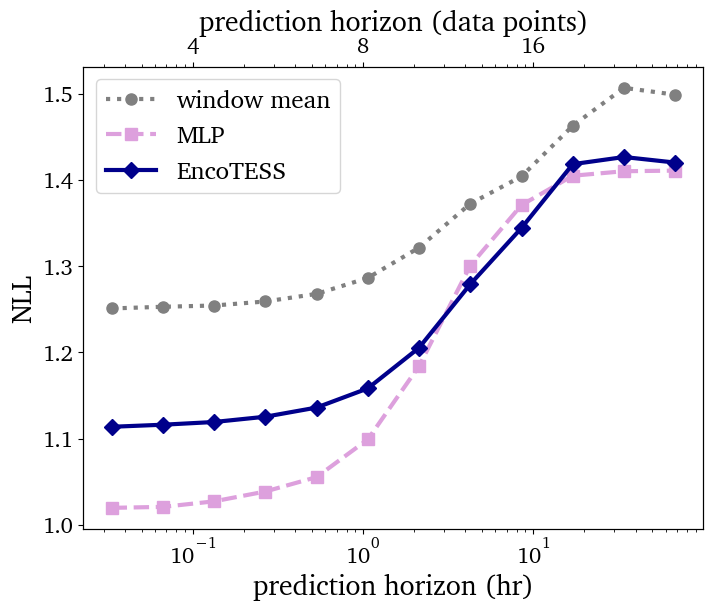

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

# Plot lines
for i in range(len(methods)):
    method = methods[i]
    method_stats = stats[stats['method'] == method]

    ax.plot(
        method_stats['k'] / 30,
        method_stats['nll_clipped'],
        label=labels[i],
        marker=markers[i],
        linestyle=linestyles[i],
        linewidth=3,
        markersize=8,
        color=colors[i]
    )

# Bottom axis
ax.set_xscale('log')
ax.set_xlabel('prediction horizon (hr)', fontsize=20)
ax.set_ylabel('NLL', fontsize=20)

ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)

ax.legend(fontsize=18)

# -----------------------------
# Top axis showing raw k values
# -----------------------------
ax_top = ax.twiny()

# Match limits and scale
ax_top.set_xscale('log')
ax_top.set_xlim(ax.get_xlim())

# Choose tick locations using actual k values
k_ticks = np.array(sorted(stats['k'].unique()))

# Bottom axis coordinates are k/30
# tick_locations = k_ticks / 30

# ax_top.set_xticks(tick_locations)
ax_top.set_xticklabels([str(k) for k in k_ticks], fontsize=16)

ax_top.set_xlabel('prediction horizon (data points)', fontsize=20)

plt.show()